In [126]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from scikeras.wrappers import KerasRegressor
import random
import os
tf.keras.utils.set_random_seed(42)
# Fijar semillas
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)


Cargar datos

In [127]:
data = load_diabetes()
X = data.data
y = data.target

Train / Test split

In [128]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("División de datos completada.")
print(f"Muestras de Entrenamiento: {X_train.shape[0]} (80%)")
print(f"Muestras de Validación:    {X_val.shape[0]} (20%)")

División de datos completada.
Muestras de Entrenamiento: 353 (80%)
Muestras de Validación:    89 (20%)


Escalar datos

In [129]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

**Modelo Base**

In [130]:
def create_model(neurons1=32, neurons2=16, learning_rate=0.001):
    model = keras.Sequential([
        keras.Input(shape=(X_train.shape[1],)),
        layers.Dense(neurons1, activation="relu"),
        layers.Dense(neurons2, activation="relu"),
        layers.Dense(1)
    ])
    
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    
    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )
    
    return model

Entreno modelo base

In [131]:
model = create_model()

history = model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=16,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 29703.6289 - mae: 153.7863 - val_loss: 26487.8320 - val_mae: 145.6074
Epoch 2/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 29485.1191 - mae: 153.1369 - val_loss: 26293.3477 - val_mae: 145.0021
Epoch 3/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 29234.2090 - mae: 152.4202 - val_loss: 26052.0332 - val_mae: 144.2718
Epoch 4/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 28907.1152 - mae: 151.5038 - val_loss: 25728.5312 - val_mae: 143.3019
Epoch 5/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 28459.5957 - mae: 150.2538 - val_loss: 25282.0371 - val_mae: 141.9723
Epoch 6/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 27830.8672 - mae: 148.4928 - val_loss: 24645.9980 - val_mae: 140.0863
Epoch 7/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 26946.5020 - mae: 145.9947 - val_loss: 23760.3672 - val_mae: 137.4445
Epoch 8/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 25748.6875 - mae: 142.5495 - val_loss: 2257

Evalúo modelo base

In [132]:
y_pred = model.predict(X_val).ravel()

mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_pred)

print("🔹 MODELO BASE")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
🔹 MODELO BASE
MAE:  44.7434
RMSE: 55.3608
R²:   0.4215


**Modifica algunos hiperparámetros del modelo (capas, neuronas, batch size, epochs, etc.) y observa cómo cambian los resultados**

Inicio una lista para comparar resultados

In [133]:
resultados = []

Función auxiliar para probar modelos

In [134]:
def entrenar_y_evaluar(nombre_modelo, neurons1, neurons2, lr, epochs, batch_size):
    
    model = create_model(neurons1=neurons1, neurons2=neurons2, learning_rate=lr)
    
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val, y_val),
        verbose=0
    )
    
    y_pred = model.predict(X_val).ravel()
    
    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2 = r2_score(y_val, y_pred)
    
    resultados.append([nombre_modelo, neurons1, neurons2, lr, epochs, batch_size, mae, rmse, r2])
    
    print(f"\n🔹 {nombre_modelo}")
    print(f"MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")
    
    return history

Realizo experimentos con diferentes valores de hiperparámetros

1. Modelo base

In [135]:
entrenar_y_evaluar(
    "Base",
    neurons1=32,
    neurons2=16,
    lr=0.001,
    epochs=60,
    batch_size=16
)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

🔹 Base
MAE: 43.4387 | RMSE: 54.0272 | R2: 0.4491


2. Más neuronas (más complejo)

In [136]:
entrenar_y_evaluar(
    "Mas neuronas",
    neurons1=64,
    neurons2=32,
    lr=0.001,
    epochs=60,
    batch_size=16
)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

🔹 Mas neuronas
MAE: 42.6844 | RMSE: 52.8456 | R2: 0.4729


3. Menos neuronas (más simple)

In [137]:
entrenar_y_evaluar(
    "Menos neuronas",
    neurons1=16,
    neurons2=8,
    lr=0.001,
    epochs=60,
    batch_size=16
)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

🔹 Menos neuronas
MAE: 52.5734 | RMSE: 67.1566 | R2: 0.1488


4. Más epochs

In [138]:
entrenar_y_evaluar(
    "Mas epochs",
    neurons1=32,
    neurons2=16,
    lr=0.001,
    epochs=150,
    batch_size=16
)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

🔹 Mas epochs
MAE: 42.5585 | RMSE: 52.7033 | R2: 0.4757


5. Batch pequeño

In [139]:
entrenar_y_evaluar(
    "Batch pequeno",
    neurons1=32,
    neurons2=16,
    lr=0.001,
    epochs=60,
    batch_size=8
)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step

🔹 Batch pequeno
MAE: 43.2084 | RMSE: 53.2917 | R2: 0.4640


6. Batch grande

In [140]:
entrenar_y_evaluar(
    "Batch grande",
    neurons1=32,
    neurons2=16,
    lr=0.001,
    epochs=60,
    batch_size=32
)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

🔹 Batch grande
MAE: 48.8738 | RMSE: 61.8666 | R2: 0.2776


7. Learning rate alto

In [141]:
entrenar_y_evaluar(
    "LR alto",
    neurons1=32,
    neurons2=16,
    lr=0.01,
    epochs=60,
    batch_size=16
)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step

🔹 LR alto
MAE: 44.0465 | RMSE: 55.2829 | R2: 0.4232


8. Learning rate bajo

In [142]:
entrenar_y_evaluar(
    "LR bajo",
    neurons1=32,
    neurons2=16,
    lr=0.0005,
    epochs=60,
    batch_size=16
)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

🔹 LR bajo
MAE: 44.5983 | RMSE: 55.8465 | R2: 0.4113


**Ver resultados**

In [143]:
import pandas as pd

df_resultados = pd.DataFrame(
    resultados,
    columns=["Modelo", "N1", "N2", "LR", "Epochs", "Batch", "MAE", "RMSE", "R2"]
)

df_resultados.sort_values(by="MAE")

,Modelo,N1,N2,LR,Epochs,Batch,MAE,RMSE,R2
3,Mas epochs,32,16,0.0010,150,16,42.558454,52.703286,0.475735
1,Mas neuronas,64,32,0.0010,60,16,42.684371,52.845582,0.472900
4,Batch pequeno,32,16,0.0010,60,8,43.208439,53.291728,0.463962
0,Base,32,16,0.0010,60,16,43.438726,54.027166,0.449065
6,LR alto,32,16,0.0100,60,16,44.046476,55.282888,0.423158
7,LR bajo,32,16,0.0005,60,16,44.598344,55.846486,0.411336
5,Batch grande,32,16,0.0010,60,32,48.873804,61.866608,0.277583
2,Menos neuronas,16,8,0.0010,60,16,52.573367,67.156621,0.148758


Se realizó una exploración manual de hiperparámetros, observándose que, al aumentar el número de épocas mejoró levemente el rendimiento, mientras que el uso de batch sizes pequeños favoreció la generalización del modelo.

Por otro lado, modelos con menor cantidad de neuronas presentaron underfitting, evidenciado en un aumento significativo del error, mientras que incrementar la complejidad no generó mejoras sustanciales.

En conjunto, estos resultados permitieron identificar configuraciones más eficientes, las cuales serán utilizadas como base para la optimización mediante RandomizedSearchCV.

**RandomizedSearch**

In [144]:
from scikeras.wrappers import KerasRegressor

model_keras = KerasRegressor(
    model=create_model,
    verbose=0
)

param_dist = {
    "model__neurons1": [16, 32, 64],
    "model__neurons2": [8, 16, 32],
    "batch_size": [8, 16, 32],
    "epochs": [50, 80, 100, 200],
    "model__learning_rate": [0.01, 0.001, 0.0005]
}

random_search = RandomizedSearchCV(
    estimator=model_keras,
    param_distributions=param_dist,
    n_iter=10,
    scoring="neg_mean_absolute_error",
    cv=3,
    verbose=1,
    random_state=42
)

random_search.fit(X_train, y_train)

print("🔹 MEJORES HIPERPARÁMETROS")
print(random_search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
🔹 MEJORES HIPERPARÁMETROS
{'model__neurons2': 16, 'model__neurons1': 64, 'model__learning_rate': 0.01, 'epochs': 200, 'batch_size': 16}


Modelo optimizado con RandomSearch

In [145]:
best_model = random_search.best_estimator_

Evaluación final

In [146]:
y_pred_opt = best_model.predict(X_val)

mae = mean_absolute_error(y_val, y_pred_opt)
mse = mean_squared_error(y_val, y_pred_opt)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_pred_opt)

print("\n🔹 MODELO OPTIMIZADO")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")


🔹 MODELO OPTIMIZADO
MAE:  41.9177
RMSE: 51.9034
R²:   0.4915


Para la selección del mejor modelo se priorizaron métricas de error como MAE y RMSE, dado que permiten evaluar directamente la precisión de las predicciones. El coeficiente R² se utilizó como métrica complementaria para analizar la capacidad explicativa del modelo.

En este contexto, el modelo optimizado mediante RandomizedSearchCV presentó el mejor desempeño global, superando tanto al modelo base como a las configuraciones evaluadas manualmente.

Esto indica que la optimización de hiperparámetros permitió mejorar significativamente la capacidad predictiva del modelo.

**Comparación visual**

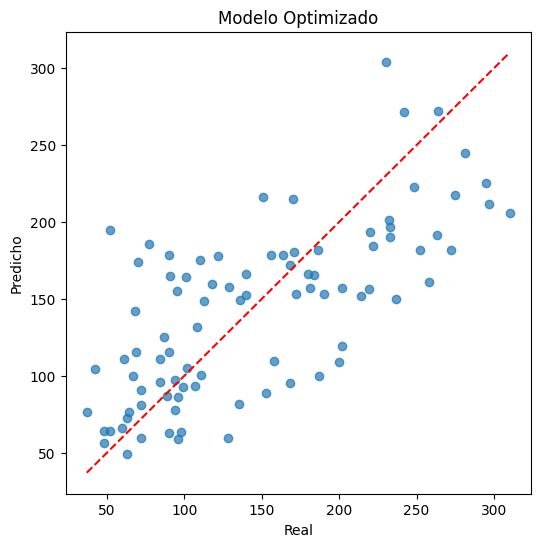

In [147]:
plt.figure(figsize=(6,6))
plt.scatter(y_val, y_pred_opt, alpha=0.7)
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.title("Modelo Optimizado")
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], "r--")
plt.show()

In [148]:
import pandas as pd

# Crear DataFrame con 10 ejemplos
df_comp = pd.DataFrame({
    "Real": y_val[:10],
    "Predicho": y_pred[:10]
})

# Calcular diferencia y error %
df_comp["Diferencia"] = df_comp["Real"] - df_comp["Predicho"]
df_comp["Error %"] = (df_comp["Diferencia"].abs() / df_comp["Real"]) * 100

# Redondear para que se vea más bonito
df_comp = df_comp.round(2)

df_comp


,Real,Predicho,Diferencia,Error %
0,219.0,173.639999,45.36,20.71
1,70.0,180.970001,-110.97,158.52
2,202.0,147.729996,54.27,26.87
3,230.0,333.989990,-103.99,45.21
4,111.0,81.580002,29.42,26.50
5,84.0,120.180000,-36.18,43.07
6,242.0,268.250000,-26.25,10.85
7,272.0,184.520004,87.48,32.16
8,94.0,65.239998,28.76,30.59
9,96.0,69.139999,26.86,27.97


In [149]:
# Promedio de métricas
prom_diferencia = df_comp["Diferencia"].abs().mean()
prom_error_pct = df_comp["Error %"].mean()

print(f"Promedio diferencia absoluta: {prom_diferencia:.2f}")
print(f"Promedio error porcentual: {prom_error_pct:.2f}%")

Promedio diferencia absoluta: 54.95
Promedio error porcentual: 42.24%


En general, se observa que el modelo logra aproximarse a los valores reales en varios casos, aunque presenta diferencias importantes en ciertas observaciones. Por ejemplo, existen predicciones con errores relativamente bajos, como en el caso de valores cercanos a 242, donde la diferencia es de aproximadamente 26 unidades (10.85%), lo que indica un buen ajuste local.

Sin embargo, también se identifican errores elevados, como en el caso de un valor real de 70, donde el modelo predice aproximadamente 181, generando un error porcentual superior al 150%. Este tipo de desviaciones sugiere que el modelo presenta dificultades para generalizar correctamente en algunos rangos de valores.

En términos generales, el modelo tiende tanto a sobreestimar como a subestimar los valores reales, lo que indica la ausencia de un sesgo sistemático claro, pero sí una variabilidad en la precisión de las predicciones.

El promedio de la diferencia absoluta fue de aproximadamente 55 unidades, mientras que el error porcentual promedio alcanzó cerca de 42%, lo que permite tener una visión global del desempeño del modelo a nivel individual de predicciones.

Estos resultados son consistentes con las métricas globales previamente obtenidas (MAE y RMSE), y reflejan que, si bien el modelo presenta una capacidad predictiva aceptable, aún existen observaciones donde el error es considerable, lo cual es esperable en problemas de regresión con datos reales y variabilidad inherente.